## **Assignment 1 (READ ALL INSTRUCTIONS)**
### **Section 1**
### Objectives:
1. Familiarize yourself with Google Colab.  
Resources: https://colab.research.google.com/  
Open/upload this file on google colab and look around, explore different options, find where the other files used in this code are located, check the available runtime options (T4 GPU connection) etc.
2. Set up Nsight Systems (NSys) in the colab notebook and on your PC.  
Nsight Systems user guide: https://docs.nvidia.com/nsight-systems/UserGuide/index.html  
Follow the code below for setting up in the colab notebook.  
Use the installation guide for your PC: https://docs.nvidia.com/nsight-systems/InstallationGuide/index.html  
Note that the colab notebook installs 2023.2.3 version of NSys, so you should install the same or higher version on your PC to ensure compatibility.

3. Learn how to use NVTX notations and read the nsys report.  
Resources: https://www.youtube.com/watch?v=kKANP0kL_hk

4. Understand the significance of specialized kernels in improving performance.

NOTE: You’re welcome to use personal GPUs, but keep in mind our Jupyter notebook is dogfooded with Google Colab (T4 GPUs). If you choose your own setup, you’ll need to handle software installations, and performance or kernel names may vary. For consistency and easier evaluation, we recommend sticking with Colab.
### Deliverables:
Submit a report with the following details:

**Part 1**
1. Locate the main process in Nsys inside the timeline view (the process taking maximum CPU time). List the process id, and % CPU usage, along with a screenshot
to show where you found it in Nsys.
2. Attach a screenshot of the timeline view from Nsys (including NVTX annotation) and briefly describe what you observe there.
3. List the cuda kernels and memory operations used by your application. Hint: use --stats option from Nsys during profiling.
4. List five metrics or insights that you can gather from the profiling results.

**Part  2**
1. Find the speedup in matrix multiplication using torch.matmul compared to naive implementation of matrix multiplication.
2. List the name of the kernel(s) used for matrix multiplication.

**Part  3**
1. Find the speedup in matrix multiplication using torch.matmul compared to naive implementation of matrix multiplication.
2. List the name of the kernel(s) used for matrix multiplication. Is it same as Part 2 kernel name(s)? If not, try to find the reason.

### **Section 2**

Part 1:

Compare the runtime distribution of various operations (conv2d, batch_norm, relu, softmax and others) for resnet50 using default (Automatic Mixed Precision (AMP)) and FP32 precision.

Part 2:

Compare the runtime distribution of different layers of the resnet 50 network architecure (stem, layer 1, layer 25, layer 50, and the final classifier) to assess performance variations across layers.
(For convolution layers include the following batch_norm and relu operations if present)

Capture and analyze a screenshot of one resnet block using Nsight Systems. Show the distribution of operations within the block.

Part 3:

Calculate and compare FLOPS/byte for conv2d, batch_norm, and other elementwise operations for resnet 50 with FP32 precision.

### Deliverables:
Submit a report detailing the above analyses. Add graphs or tables and explain your observations.

## Upload the *zip file* of assignment in Brightspace containing:
1. Report Section 1: **Section1_Lastname_Firstname.pdf**
2. Report Section 2: **Section2_Lastname_Firstname.pdf**
2. Colab:  **Lastname_Firstname.ipynb**

Filename: **Assignment1_Lastname_Firstname.zip**

# **Section 1**

**Initial Setup**

In [1]:
# verify that GPU is selected for compute
!nvidia-smi
#Tesla T4

Tue Mar 10 02:42:06 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   60C    P8             14W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
!nvcc --version

nvcc: NVIDIA (R) Cuda compiler driver
Copyright (c) 2005-2025 NVIDIA Corporation
Built on Fri_Feb_21_20:23:50_PST_2025
Cuda compilation tools, release 12.8, V12.8.93
Build cuda_12.8.r12.8/compiler.35583870_0


Install Nsight Systems.

In [3]:
!wget https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64/nsight-systems-2023.2.3_2023.2.3.1001-1_amd64.deb
!apt update
!apt install ./nsight-systems-2023.2.3_2023.2.3.1001-1_amd64.deb
!apt --fix-broken install

--2026-03-10 02:42:09--  https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64/nsight-systems-2023.2.3_2023.2.3.1001-1_amd64.deb
Resolving developer.download.nvidia.com (developer.download.nvidia.com)... 23.59.88.3, 23.59.88.9, 23.59.88.4, ...
Connecting to developer.download.nvidia.com (developer.download.nvidia.com)|23.59.88.3|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 317705436 (303M) [application/x-deb]
Saving to: ‘nsight-systems-2023.2.3_2023.2.3.1001-1_amd64.deb’

nsight-systems-2023 100%[===================>] 302.99M  30.8MB/s    in 5.1s    

2026-03-10 02:42:14 (59.6 MB/s) - ‘nsight-systems-2023.2.3_2023.2.3.1001-1_amd64.deb’ saved [317705436/317705436]

Get:1 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,581 B]
Get:2 https://cli.github.com/packages stable InRelease [3,917 B]
Get:3 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:4 https://developer.download.nvi

Ensure the kernel paranoid level is set to 2.

In [4]:
!nsys status -e

Timestamp counter supported: Yes

CPU Profiling Environment Check
Root privilege: enabled
Linux Kernel Paranoid Level = 2
Linux Distribution = Ubuntu
Linux Kernel Version = 6.6.113+: OK
Linux perf_event_open syscall available: OK
Sampling trigger event available: OK
Intel(c) Last Branch Record support: Not Available
CPU Profiling Environment (process-tree): OK
CPU Profiling Environment (system-wide): OK

See the product documentation at https://docs.nvidia.com/nsight-systems for more information,
including information on how to set the Linux Kernel Paranoid Level.


In [5]:
!nsys --version

NVIDIA Nsight Systems version 2023.2.3.1001-32894139v0


In [6]:
# check if cuda is available
import torch

if torch.cuda.is_available():
    print("CUDA is available")
else:
    print("CUDA is not available")

CUDA is available


In [7]:
# Implement naive matrix multiplication function
# Note: Correct implementation will output True
import time
t0 = time.time()

import torch

def naive_matrix_multiplication(A, B):
    """Compute matrix multiplication A x B using Python for loops."""
    # A: shape (n, k)
    # B: shape (k, m)
    n = A.shape[0]
    k = A.shape[1]
    m = B.shape[1]
    C = torch.zeros(n, m, dtype=A.dtype).to("cuda")

    # <FILL IN code for Matrix Multiplication>
    for i in range(n):
      for j in range(m):
        for k_idx in range(k):
          C[i, j] += A[i, k_idx] * B[k_idx, j]

    return C


#instantiate two random matrix
x = torch.ones(16, 64).to("cuda")
y = torch.ones(64, 32).to("cuda")
z = naive_matrix_multiplication(x,y)
t1 = time.time()
print("time taken: ", t1 - t0)

# Testing naive matmul implementation
z_gold = torch.matmul(x,y)
print(torch.eq(z_gold, z).all())

time taken:  1.5203862190246582
tensor(True, device='cuda:0')


## **Part 1**

In [8]:
%%writefile nsys_demo0.py

import torch
import nvtx

def naive_matrix_multiplication(A, B):
    """Compute matrix multiplication A x B using Python for loops."""
    # A: shape (n, k)
    # B: shape (k, m)
    n = A.shape[0]
    k = A.shape[1]
    m = B.shape[1]
    C = torch.zeros(n, m, dtype=A.dtype).to("cuda")

    # <FILL IN code for Matrix Multiplication>
    for i in range(n):
      for j in range(m):
        for k_idx in range(k):
          C[i, j] += A[i, k_idx] * B[k_idx, j]
    return C


# instantiate two random matrix
# Note: do not change the size of matrix here for facilitate ease in evaluation
x = torch.rand(16, 64).to("cuda")
y = torch.rand(64, 32).to("cuda")
# warmup
z = naive_matrix_multiplication(x,y)
torch.cuda.synchronize()
# profile
for i in range(11):
    torch.cuda.nvtx.range_push("matmul")
    z = naive_matrix_multiplication(x, y)
    torch.cuda.synchronize()
    torch.cuda.nvtx.range_pop()


Writing nsys_demo0.py


Important commands for nsight systems: profile, export, stats
(Refer the user guide for more details)

In [9]:
import time
t0 = time.time()
!nsys profile -f true --stats=true -o nsys_demo0 python nsys_demo0.py
t1 = time.time()
print("time taken: ", (t1 - t0)/9)

Generating '/tmp/nsys-report-131a.qdstrm'
[1/8] [========================100%] nsys_demo0.nsys-rep
[2/8] [========================100%] nsys_demo0.sqlite
[3/8] Executing 'nvtx_sum' stats report

 Time (%)  Total Time (ns)  Instances     Avg (ns)         Med (ns)        Min (ns)       Max (ns)      StdDev (ns)    Style   Range 
 --------  ---------------  ---------  ---------------  ---------------  -------------  -------------  -------------  -------  ------
    100.0   33,966,383,985         11  3,087,853,089.5  2,840,343,986.0  2,624,966,908  4,428,846,296  610,713,304.1  PushPop  matmul

[4/8] Executing 'osrt_sum' stats report

 Time (%)  Total Time (ns)  Num Calls     Avg (ns)      Med (ns)     Min (ns)    Max (ns)    StdDev (ns)            Name         
 --------  ---------------  ----------  ------------  -------------  ---------  -----------  ------------  ----------------------
     98.0   41,503,907,448         422  98,350,491.6  100,147,414.5      1,481  360,639,977  20,204,1

In [11]:
from google.colab import files

#!nsys stats /content/nsys_demo0.nsys-rep
!nsys stats --report cuda_gpu_kern_sum nsys_demo0.sqlite \
  --report nvtx_sum \
  --format csv \
  --output /content/nsys_demo0.nsys-rep \
# Replace 'nsys_demo.nsys-rep' with the path to your file
#files.download('/content/nsys_demo0.nsys-rep')



Processing [nsys_demo0.sqlite] with [/opt/nvidia/nsight-systems/2023.2.3/host-linux-x64/reports/cuda_gpu_kern_sum.py] to [/content/nsys_demo0.nsys-rep_cuda_gpu_kern_sum.csv]... SKIPPED: output file /content/nsys_demo0.nsys-rep_cuda_gpu_kern_sum.csv exists.

Processing [nsys_demo0.sqlite] with [/opt/nvidia/nsight-systems/2023.2.3/host-linux-x64/reports/nvtx_sum.py] to [/content/nsys_demo0.nsys-rep_nvtx_sum.csv]... SKIPPED: output file /content/nsys_demo0.nsys-rep_nvtx_sum.csv exists.



Launch Nsight Systems from your PC and open the downloaded nsys-rep file.

Sample Output from Nsys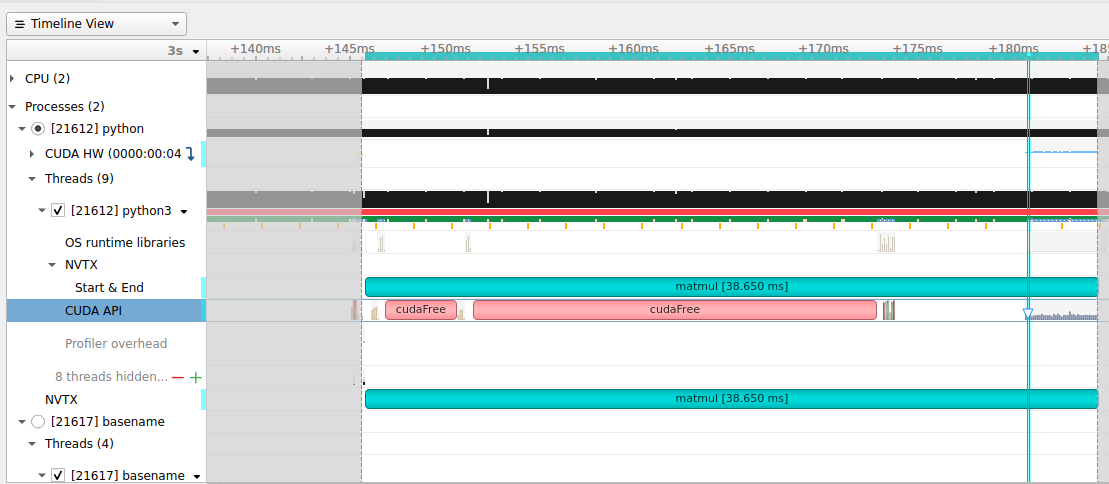

**Deliverables Part 1**
1. Locate the main process in Nsys inside the timeline view (the process taking maximum CPU time). List the process id, and % CPU usage, along with a screenshot
to show where you found it in Nsys.
2. Attach a screenshot of the timeline view from Nsys (including NVTX annotation) and briefly describe what you observe there.
3. List the cuda kernels and memory operations used by your application. Hint: use --stats option from Nsys during profiling.
4. List five metrics or insights that you can gather from the profiling results.

## **Part 2**

In [12]:
%%writefile nsys_demo1.py

import torch
import nvtx

# instantiate two random matrix
# Note: do not change the size of matrix here for facilitate ease in evaluation
x = torch.rand(16, 64).to("cuda")
y = torch.rand(64, 32).to("cuda")
# warmup
z = torch.matmul(x,y)
torch.cuda.synchronize()
# profile
for i in range(51):
    torch.cuda.nvtx.range_push("matmul")
    z = torch.matmul(x,y)
    torch.cuda.synchronize()
    torch.cuda.nvtx.range_pop()

# for i in range(51):
#   torch.cuda.synchronize()
#   start = nvtx.start_range(message="matmul", color="blue")
#   z = torch.matmul(x,y)
#   nvtx.end_range(start)


Writing nsys_demo1.py


In [13]:
import time
from IPython.display import display, Markdown
t0 = time.time()
!nsys profile -f true --stats=true -o nsys_demo1 python nsys_demo1.py #> nsys_demo1.txt
#display(Markdown("/content/nsys_demo1.txt"))
t1 = time.time()
print("time taken: ", (t1 - t0)/9)

Generating '/tmp/nsys-report-0289.qdstrm'
[1/8] [========================100%] nsys_demo1.nsys-rep
[2/8] [========================100%] nsys_demo1.sqlite
[3/8] Executing 'nvtx_sum' stats report

 Time (%)  Total Time (ns)  Instances  Avg (ns)  Med (ns)  Min (ns)  Max (ns)  StdDev (ns)   Style   Range 
 --------  ---------------  ---------  --------  --------  --------  --------  -----------  -------  ------
    100.0        2,499,187         51  49,003.7  43,401.0    40,775   157,972     17,038.0  PushPop  matmul

[4/8] Executing 'osrt_sum' stats report

 Time (%)  Total Time (ns)  Num Calls    Avg (ns)      Med (ns)    Min (ns)    Max (ns)    StdDev (ns)            Name         
 --------  ---------------  ---------  ------------  ------------  ---------  -----------  ------------  ----------------------
     73.0      878,077,932         18  48,782,107.3  20,701,229.0      1,663  277,186,693  69,418,780.7  poll                  
     23.4      281,296,108        624     450,795.0    

In [ ]:
from google.colab import files
files.download('/content/nsys_demo1.nsys-rep')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

**Deliverables Part  2**
1. Find the speedup in matrix multiplication using torch.matmul compared to naive implementation of matrix multiplication.
2. List the name of the kernel(s) used for matrix multiplication.


## **Part 3**

In [14]:
%%writefile nsys_demo2.py

import torch
import nvtx

def naive_matrix_multiplication(A, B):
    """Compute matrix multiplication A x B using Python for loops."""
    # A: shape (n, k)
    # B: shape (k, m)
    n = A.shape[0]
    k = A.shape[1]
    m = B.shape[1]
    C = torch.zeros(n, m, dtype=A.dtype).to("cuda")

    # <FILL IN code for Matrix Multiplication, can copy from your part 1 solution>
    for i in range(n):
      for j in range(m):
        for k_idx in range(k):
          C[i, j] += A[i, k_idx] * B[k_idx, j]

    return C


# instantiate two random matrix
# Note: do not change the size of matrix here for facilitate ease in evaluation
x = torch.rand(32, 64).to("cuda")
y = torch.rand(64, 32).to("cuda")
# warmup
z = torch.matmul(x,y)
torch.cuda.synchronize()

# profile
# for i in range(11):
#   start = nvtx.start_range(message="naive", color="blue")
#   z = naive_matrix_multiplication(x,y)
#   torch.cuda.synchronize()
#   nvtx.end_range(start)

# for i in range(11):
#   start = nvtx.start_range(message="volta", color="orange")
#   z = torch.matmul(x,y)
#   torch.cuda.synchronize()
#   nvtx.end_range(start)

for i in range(11):
    torch.cuda.nvtx.range_push("naive")
    z = naive_matrix_multiplication(x, y)
    torch.cuda.synchronize()
    torch.cuda.nvtx.range_pop()

for i in range(11):
    torch.cuda.nvtx.range_push("volta")
    z = torch.matmul(x,y)
    torch.cuda.synchronize()
    torch.cuda.nvtx.range_pop()


Writing nsys_demo2.py


In [15]:
import time
t0 = time.time()
!nsys profile -f true --stats=true -o nsys_demo2 python nsys_demo2.py
t1 = time.time()
print("time taken: ", (t1 - t0)/9)

Generating '/tmp/nsys-report-9aec.qdstrm'
[1/8] [========================100%] nsys_demo2.nsys-rep
[2/8] [========================100%] nsys_demo2.sqlite
[3/8] Executing 'nvtx_sum' stats report

 Time (%)  Total Time (ns)  Instances     Avg (ns)         Med (ns)        Min (ns)       Max (ns)      StdDev (ns)    Style   Range
 --------  ---------------  ---------  ---------------  ---------------  -------------  -------------  -------------  -------  -----
    100.0   68,206,609,971         11  6,200,600,906.5  6,081,690,417.0  5,531,583,544  7,032,935,692  583,762,802.1  PushPop  naive
      0.0          701,170         11         63,742.7         46,894.0         43,426        205,853       47,722.1  PushPop  volta

[4/8] Executing 'osrt_sum' stats report

 Time (%)  Total Time (ns)  Num Calls     Avg (ns)      Med (ns)     Min (ns)    Max (ns)    StdDev (ns)            Name         
 --------  ---------------  ----------  ------------  -------------  ---------  -----------  --------

In [17]:
!nsys stats --report cuda_gpu_kern_sum nsys_demo2.sqlite \
  --report nvtx_sum \
  --format csv \
  --output /content/nsys_demo2.nsys-rep \


#files.download('/content/nsys_demo2.nsys-rep')

Processing [nsys_demo2.sqlite] with [/opt/nvidia/nsight-systems/2023.2.3/host-linux-x64/reports/cuda_gpu_kern_sum.py] to [/content/nsys_demo2.nsys-rep_cuda_gpu_kern_sum.csv]... PROCESSED

Processing [nsys_demo2.sqlite] with [/opt/nvidia/nsight-systems/2023.2.3/host-linux-x64/reports/nvtx_sum.py] to [/content/nsys_demo2.nsys-rep_nvtx_sum.csv]... PROCESSED



**Deliverables Part  3**
1. Find the speedup in matrix multiplication using torch.matmul compared to naive implementation of matrix multiplication.
2. List the name of the kernel(s) used for matrix multiplication. Is it same as Part 2 kernel name(s)? If not, try to find the reason.


# **Section 2**

**Initial Setup**

In [18]:
!nvidia-smi
#Tesla T4

Tue Mar 10 03:06:32 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   72C    P0             30W /   70W |     153MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [20]:
!nvcc --version

nvcc: NVIDIA (R) Cuda compiler driver
Copyright (c) 2005-2025 NVIDIA Corporation
Built on Fri_Feb_21_20:23:50_PST_2025
Cuda compilation tools, release 12.8, V12.8.93
Build cuda_12.8.r12.8/compiler.35583870_0


Install Nsight Systems. User guide: https://docs.nvidia.com/nsight-systems/UserGuide/index.html

In [21]:
!wget https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64/nsight-systems-2023.2.3_2023.2.3.1001-1_amd64.deb
!apt update
!apt install ./nsight-systems-2023.2.3_2023.2.3.1001-1_amd64.deb
!apt --fix-broken install

--2026-03-10 03:06:35--  https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64/nsight-systems-2023.2.3_2023.2.3.1001-1_amd64.deb
Resolving developer.download.nvidia.com (developer.download.nvidia.com)... 23.59.88.4, 23.59.88.13, 23.59.88.3, ...
Connecting to developer.download.nvidia.com (developer.download.nvidia.com)|23.59.88.4|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 317705436 (303M) [application/x-deb]
Saving to: ‘nsight-systems-2023.2.3_2023.2.3.1001-1_amd64.deb.1’

nsight-systems-2023 100%[===================>] 302.99M   306MB/s    in 1.0s    

2026-03-10 03:06:36 (306 MB/s) - ‘nsight-systems-2023.2.3_2023.2.3.1001-1_amd64.deb.1’ saved [317705436/317705436]

Hit:1 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:2 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease
Get:3 https://cli.github.com/packages stable InRelease [3,917 B]
Hit:4 https://r2u.stat.illinois.edu/ubunt

Ensure the kernel paranoid level is set to 2.

In [22]:
!nsys status -e

Timestamp counter supported: Yes

CPU Profiling Environment Check
Root privilege: enabled
Linux Kernel Paranoid Level = 2
Linux Distribution = Ubuntu
Linux Kernel Version = 6.6.113+: OK
Linux perf_event_open syscall available: OK
Sampling trigger event available: OK
Intel(c) Last Branch Record support: Not Available
CPU Profiling Environment (process-tree): OK
CPU Profiling Environment (system-wide): OK

See the product documentation at https://docs.nvidia.com/nsight-systems for more information,
including information on how to set the Linux Kernel Paranoid Level.


In [23]:
!nsys --version

NVIDIA Nsight Systems version 2023.2.3.1001-32894139v0


In [24]:
# prompt: check if cuda is available
import torch

if torch.cuda.is_available():
    print("CUDA is available")
else:
    print("CUDA is not available")

CUDA is available


In [25]:
!pip install git+https://github.com/NVIDIA/dllogger#egg=dllogger

  Cloning https://github.com/NVIDIA/dllogger to /tmp/pip-install-dfygsnzr/dllogger_3b64e8401e1d4c369506626fafba9c84
  Running command git clone --filter=blob:none --quiet https://github.com/NVIDIA/dllogger /tmp/pip-install-dfygsnzr/dllogger_3b64e8401e1d4c369506626fafba9c84
  Resolved https://github.com/NVIDIA/dllogger to commit 0478734ff7be75adde8d160e04872664d1c62e5f
  Preparing metadata (setup.py) ... done
  Created wheel for dllogger: filename=DLLogger-1.1.0-py3-none-any.whl size=5659 sha256=22a466ecbdf1fad4371d7a07cc5d8f65df2df6cb961d51a8d00ddcfb5215c480
  Stored in directory: /tmp/pip-ephem-wheel-cache-30hgrk9a/wheels/b7/35/f7/c8af10d415c5b5c64b0bf6e59c6d5a33da112dce1882cc47c1
Successfully built dllogger


In [26]:
!pip install nvidia-dali-cuda120

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 418.3/418.3 MB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.5/66.5 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 40.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.4/7.4 MB 52.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 53.6 MB/s eta 0:00:00
  Attempting uninstall: packaging
    Found existing installation: packaging 26.0
    Uninstalling packaging-26.0:
      Successfully uninstalled packaging-26.0


In [27]:
!pip install pynvml

In [28]:
!pip install -U 'git+https://github.com/NVIDIA/PyProf.git'

  Cloning https://github.com/NVIDIA/PyProf.git to /tmp/pip-req-build-1atfzttu
  Running command git clone --filter=blob:none --quiet https://github.com/NVIDIA/PyProf.git /tmp/pip-req-build-1atfzttu
  Resolved https://github.com/NVIDIA/PyProf.git to commit 218dcc183bf7fdf97dbfc648878a3d09aea3b199
  Preparing metadata (setup.py) ... done
  Created wheel for nvidia-pyprof: filename=nvidia_pyprof-3.11.0-py3-none-any.whl size=86598 sha256=2e35d75ee2a3ac1d0e289887818f9bb3389c12125940cfdfd0b4e44392c2dff0
  Stored in directory: /tmp/pip-ephem-wheel-cache-gcw1bk0t/wheels/a2/16/cf/dba06791ba10f9181fbc2375d88ad5efc54021a176c8788a2b
Successfully built nvidia-pyprof


In [47]:
from google.colab import files

# Upload the file
uploaded = files.upload("/content/")

KeyboardInterrupt: 

## **Part 1**

In [52]:
!git clone https://github.com/NVIDIA/DeepLearningExamples.git

Cloning into 'DeepLearningExamples'...
remote: Enumerating objects: 33828, done.
remote: Total 33828 (delta 0), reused 0 (delta 0), pack-reused 33828 (from 1)
Receiving objects: 100% (33828/33828), 110.31 MiB | 31.15 MiB/s, done.
Resolving deltas: 100% (23824/23824), done.


In [54]:
import os
new_dir = "/content/DeepLearningExamples/PyTorch/Classification/ConvNets"
os.chdir(new_dir)

Verify if you are able to use resnet50 for image classification. You can try different images as input here.

In [56]:
!python classify.py --arch resnet50 --image /content/ui_goku.jpg

/usr/local/lib/python3.12/dist-packages/torch/cuda/__init__.py:65: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
/content/DeepLearningExamples/PyTorch/Classification/ConvNets/image_classification/models/common.py:13: UserWarning: pytorch_quantization module not found, quantization will not be available
  warnings.warn(
/content/DeepLearningExamples/PyTorch/Classification/ConvNets/image_classification/models/efficientnet.py:17: UserWarning: pytorch_quantization module not found, quantization will not be available
  warnings.warn(
/content/DeepLearningExamples/PyTorch/Classification/ConvNets/classify.py:142: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.no_grad(), autocast(enabled=args.precision == 

The classify.py uses [automatic mixed precision](https://pytorch.org/docs/stable/amp.html) quantization by default. Find out the other precision options and how to use them.  
*Hint: Look at classify.py.*

Also, add the following lines to classify.py file:  

**Import cuda profiler:**  
import torch.cuda.profiler as profiler

 import pyprof  
 pyprof.init()  

 *Note: pyprof is required to enable NVTX markers for pytorch operations. This can be skipped if we don't need high level pytorch semantics.*

Add the start and stop commands where the neural network model is called.

 profiler.start()  
 profiler.stop()

Profile Resnet 50 for a single image inference with default precision.

In [42]:
!nsys profile --trace 'nvtx,cuda,osrt,cudnn' -c cudaProfilerApi --cuda-memory-usage true \
  --show-output true --sample=cpu --export=sqlite \
  -f true \
  --stats true\
  --gpu-metrics-device=all \
  -o /content/resnet50AMP \
  python classify.py --arch resnet50 --image /content/ui_goku.jpg --precision AMP


GPU 0: General Metrics for NVIDIA TU10x (any frequency)
/usr/local/lib/python3.12/dist-packages/torch/cuda/__init__.py:65: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
/content/DeepLearningExamples/PyTorch/Classification/ConvNets/image_classification/models/common.py:13: UserWarning: pytorch_quantization module not found, quantization will not be available
  warnings.warn(
/content/DeepLearningExamples/PyTorch/Classification/ConvNets/image_classification/models/efficientnet.py:17: UserWarning: pytorch_quantization module not found, quantization will not be available
  warnings.warn(
/content/DeepLearningExamples/PyTorch/Classification/ConvNets/classify.py:137: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  w

Profile Resnet 50 for a single image inference with FP32 precision.

In [43]:
# Fill Code here
!nsys profile --trace 'nvtx,cuda,osrt,cudnn' -c cudaProfilerApi --cuda-memory-usage true \
  --show-output true --sample=cpu --export=sqlite \
  -f true \
  --stats true\
  --gpu-metrics-device=all \
  -o /content/resnet50FP32 \
  python classify.py --arch resnet50 --image /content/ui_goku.jpg --precision FP32


GPU 0: General Metrics for NVIDIA TU10x (any frequency)
/usr/local/lib/python3.12/dist-packages/torch/cuda/__init__.py:65: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
/content/DeepLearningExamples/PyTorch/Classification/ConvNets/image_classification/models/common.py:13: UserWarning: pytorch_quantization module not found, quantization will not be available
  warnings.warn(
/content/DeepLearningExamples/PyTorch/Classification/ConvNets/image_classification/models/efficientnet.py:17: UserWarning: pytorch_quantization module not found, quantization will not be available
  warnings.warn(
/content/DeepLearningExamples/PyTorch/Classification/ConvNets/classify.py:137: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  w

Export the required reports in csv if required.  
Compare the runtime distribution of various operations (conv2d, batch_norm, relu, softmax and others) for resnet50 using default (Automatic Mixed Precision (AMP)) and FP32 precision.

In [57]:
# !nsys stats --help

!nsys stats \
  --report cuda_gpu_kern_sum \
  --report cuda_api_sum \
  --report osrt_sum \
  --report nvtx_sum \
  --report cudnn_api_sum \
  --format csv \
  --output /content/resnet50AMP.nsys-rep \
  /content/resnet50AMP.sqlite


!nsys stats \
  --report cuda_gpu_kern_sum \
  --report cuda_api_sum \
  --report osrt_sum \
  --report nvtx_sum \
  --report cudnn_api_sum \
  --format csv \
  --output /content/resnet50FP32.nsys-rep \
  /content/resnet50FP32.sqlite

## **Part 2**

Note: Finding the resnet network implementation and adding your own nvtx annotations (see assignment step 1) will make this part easier. Another approach is to use nsys stats to generate an NVTX report in CSV format, which can then be visualized.

1. Compare the runtime distribution of different layers of the resnet 50 network architecure (stem, layer 1, layer 25, layer 50, and the final classifier) to assess performance variations across layers.  
(For convolution layers include the following batch_norm and relu operations if present)

2. Capture and analyze a screenshot of one resnet block using Nsight Systems. Show the distribution of operations within the block.

<Figure size 1000x600 with 0 Axes>

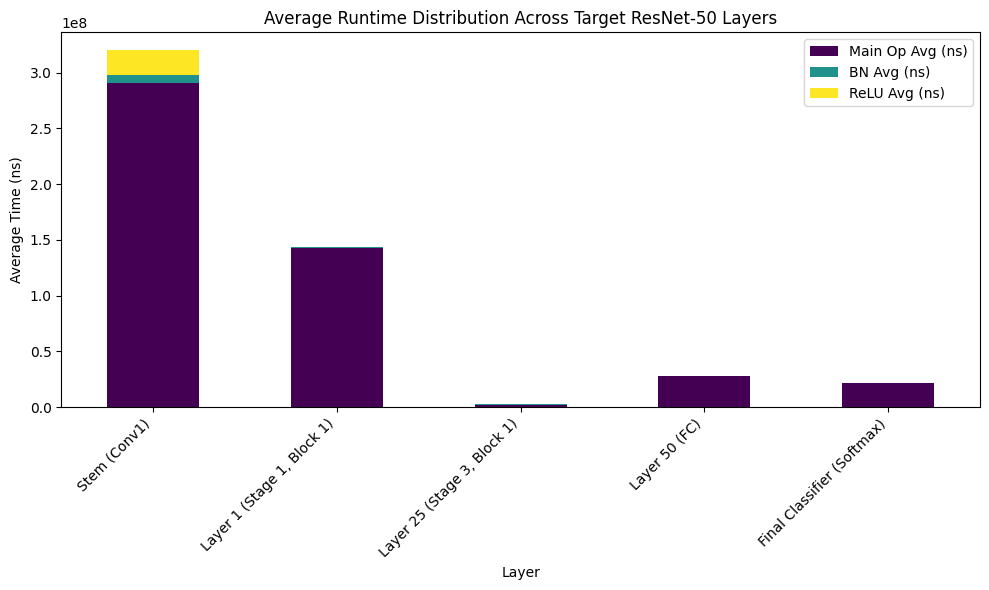

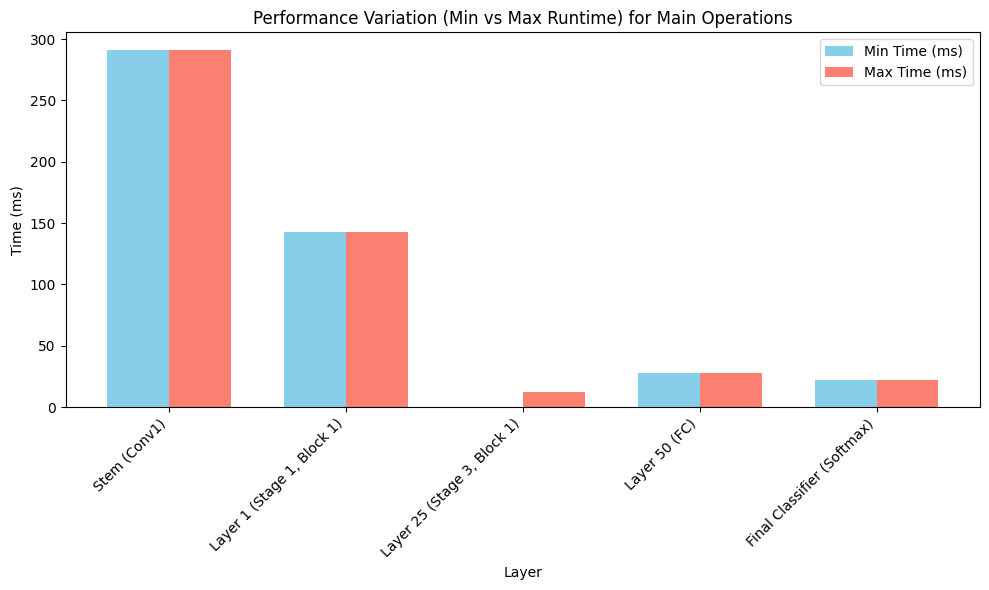

In [ ]:
# Add code here.
# Or, you can download the reports and perform the analysis locally and add relevant figures in the report.

import pandas as pd
import ast
import matplotlib.pyplot as plt
import numpy as np

def get_op_details(df):
    ops = []
    # Parse the abstract syntax trees out of the Range string representation
    for index, row in df.iterrows():
        try:
            r = row['Range']
            d = ast.literal_eval(r)
            if 'op' in d and 'mod' in d:
                op_name = d['op']
                args = d['args']

                weight_shape, input_shape = None, None

                # Weight shape is passed as the second argument in PyTorch functionals
                if op_name in ['conv2d', 'linear']:
                    if len(args) >= 2 and args[1]['type'] == 'tensor':
                        weight_shape = args[1]['shape']

                # Input shape is passed as the first argument (applies for bn/relu too)
                if len(args) >= 1 and args[0]['type'] == 'tensor':
                    input_shape = args[0]['shape']

                ops.append({
                    'op': op_name,
                    'weight_shape': weight_shape,
                    'input_shape': input_shape,
                    'Avg (ns)': row['Avg (ns)'],
                    'Min (ns)': row['Min (ns)'],
                    'Max (ns)': row['Max (ns)'],
                    'StdDev (ns)': row['StdDev (ns)'],
                    'Instances': row['Instances']
                })
        except Exception:
            pass
    return pd.DataFrame(ops)

# 1. Read the summary profiling file
df = pd.read_csv("/content/resnet50AMP.nsys-rep_nvtx_sum.csv")
ops_df = get_op_details(df)

# 2. Define the exact PyTorch Tensor shapes indicating the targeted ResNet50 layers
layers_of_interest = {
    "Stem (Conv1)": {
        "conv_op": "conv2d", "conv_weight": (64, 3, 7, 7), "out_shape": (1, 64, 112, 112),
        "has_bn": True, "has_relu": True
    },
    "Layer 1 (Stage 1, Block 1)": {
        "conv_op": "conv2d", "conv_weight": (64, 64, 1, 1), "out_shape": (1, 64, 56, 56),
        "has_bn": True, "has_relu": True
    },
    "Layer 25 (Stage 3, Block 1)": {
        "conv_op": "conv2d", "conv_weight": (1024, 256, 1, 1), "out_shape": (1, 1024, 14, 14),
        "has_bn": True, "has_relu": True
    },
    "Layer 50 (FC)": {
        "conv_op": "linear", "conv_weight": (1000, 2048), "out_shape": None,
        "has_bn": False, "has_relu": False
    },
    "Final Classifier (Softmax)": {
        "conv_op": "softmax", "conv_weight": None, "out_shape": (1, 1000),
        "has_bn": False, "has_relu": False
    }
}

results = []

# Correlate convolutions with their ensuing batch_norms and relus
for layer_name, spec in layers_of_interest.items():
    layer_stats = {'Layer': layer_name, 'Total Avg (ns)': 0}

    # Locate Main Op (Conv2d, Linear, or Softmax)
    if spec['conv_op'] == 'softmax':
        c_rows = ops_df[(ops_df['op'] == 'softmax') & (ops_df['input_shape'] == spec['out_shape'])]
    else:
        c_rows = ops_df[(ops_df['op'] == spec['conv_op']) & (ops_df['weight_shape'] == spec['conv_weight'])]

    if not c_rows.empty:
        c_row = c_rows.iloc[0]
        layer_stats['Main Op Avg (ns)'] = c_row['Avg (ns)']
        layer_stats['Main Op Min (ns)'] = c_row['Min (ns)']
        layer_stats['Main Op Max (ns)'] = c_row['Max (ns)']
        layer_stats['Total Avg (ns)'] += c_row['Avg (ns)']
    else:
        layer_stats['Main Op Avg (ns)'] = 0
        layer_stats['Main Op Min (ns)'] = 0
        layer_stats['Main Op Max (ns)'] = 0

    # Locate ensuing Batch Norm based on output tensor shapes
    if spec['has_bn'] and spec['out_shape']:
        bn_rows = ops_df[(ops_df['op'] == 'batch_norm') & (ops_df['input_shape'] == spec['out_shape'])]
        if not bn_rows.empty:
            bn_row = bn_rows.iloc[0]
            layer_stats['BN Avg (ns)'] = bn_row['Avg (ns)']
            layer_stats['Total Avg (ns)'] += bn_row['Avg (ns)']
        else:
            layer_stats['BN Avg (ns)'] = 0
    else:
        layer_stats['BN Avg (ns)'] = 0

    # Locate ensuing ReLU based on output tensor shapes
    if spec['has_relu'] and spec['out_shape']:
        relu_rows = ops_df[(ops_df['op'] == 'relu') & (ops_df['input_shape'] == spec['out_shape'])]
        if not relu_rows.empty:
            r_row = relu_rows.iloc[0]
            layer_stats['ReLU Avg (ns)'] = r_row['Avg (ns)']
            layer_stats['Total Avg (ns)'] += r_row['Avg (ns)']
        else:
            layer_stats['ReLU Avg (ns)'] = 0
    else:
        layer_stats['ReLU Avg (ns)'] = 0

    results.append(layer_stats)

res_df = pd.DataFrame(results)

# Generate Performance Variation Comparisons

# Average distribution chart
plt.figure(figsize=(10, 6))
res_df.set_index('Layer')[['Main Op Avg (ns)', 'BN Avg (ns)', 'ReLU Avg (ns)']].plot(
    kind='bar', stacked=True, figsize=(10, 6), colormap='viridis'
)
plt.title('Average Runtime Distribution Across Target ResNet-50 Layers')
plt.ylabel('Average Time (ns)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('layer_distribution.png')

# Min vs Max performance jitter chart
plt.figure(figsize=(10, 6))
bar_width = 0.35
index = np.arange(len(res_df))

plt.bar(index, res_df['Main Op Min (ns)'] / 1e6, bar_width, label='Min Time (ms)', color='skyblue')
plt.bar(index + bar_width, res_df['Main Op Max (ns)'] / 1e6, bar_width, label='Max Time (ms)', color='salmon')

plt.title('Performance Variation (Min vs Max Runtime) for Main Operations')
plt.xlabel('Layer')
plt.ylabel('Time (ms)')
plt.xticks(index + bar_width / 2, res_df['Layer'], rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.savefig('layer_variations.png')

# Export to CSV format
res_df.to_csv('resnet50_layers_runtime_comparison.csv', index=False)



## **Part 3**
1. Calculate and compare FLOPS/byte for conv2d, batch_norm, and other elementwise operations for resnet 50 with FP32 precision. How does this vary between operations that use tensor cores (tc) vs those that don't?

In [ ]:
# Suggested method:
# Parse the sqlite file to generate a dictionary
#!python -m pyprof.parse "/content/resnet50FP32.sqlite"
!python -m pyprof.parse "/content/resnet50FP32.sqlite" > netFP32.dict

#!python -m pyprof.parse "/content/resnet50AMP.sqlite" > netAMP.dict

# Analyze the dictionary
# See availalable options
# !python -m pyprof.prof netFP32.dict --help
# Example command: !python -m pyprof.prof netFP32.dict -w 150 -c idx,trace,sil,tc,flops,bytes,op,kernel

# Add code to filter and aggreage the data from the dictionary by operation type and/or tensor core usage and generate the required outputs for this part.

import ast
import math
import pandas as pd


# Load dict

with open("netFP32.dict") as f:
    s = f.read()

s = s.strip()
try:
    data = ast.literal_eval(s)
    if isinstance(data, dict):
        data = [data]
except (SyntaxError, ValueError):
    data = [ast.literal_eval(line) for line in s.splitlines() if line.strip()]


# Convert to DataFrame

df = pd.DataFrame(data)


# Flatten list columns

df["op"]  = df["op"].apply(lambda x: x[0] if isinstance(x, list) else x)
df["mod"] = df["mod"].apply(lambda x: x[0] if isinstance(x, list) else x) if "mod" in df.columns else "unknown"


# Tensor-core usage
# Prefer the 'tc' field if pyprof populated it; otherwise infer from the
# kernel name.  Tensor-core kernels carry substrings like 'hmma', 'h884',
# 's16816' (Ampere), 'i8816' (INT8) in their short/long names.

TC_SIGNATURES = ("hmma", "h884", "s16816", "i8816", "bf16gemm")

def infer_tc(row):
    # If pyprof wrote a non-zero tc field, trust it
    if "tc" in row and pd.notna(row["tc"]) and int(row["tc"]) != 0:
        return 1
    # Otherwise inspect kernel name
    kname = str(row.get("kShortName", "") or "") + str(row.get("kLongName", "") or "")
    kname = kname.lower()
    return 1 if any(sig in kname for sig in TC_SIGNATURES) else 0

df["tc"] = df.apply(infer_tc, axis=1)


# Kernel duration (ns → µs)

df["duration_us"] = pd.to_numeric(
    df["kDuration"] if "kDuration" in df.columns else pd.Series(0, index=df.index),
    errors="coerce"
).fillna(0) / 1000.0


# Compute FLOPS and bytes from marker tensor shapes

DTYPE_BYTES = {"float32": 4, "float16": 2, "float64": 8, "int32": 4, "int64": 8}

def get_tuple_arg(args, index):
    """Safely extract the value of the tuple arg at position `index`."""
    if index < len(args) and args[index].get("type") == "tuple":
        val = args[index].get("value", (1, 1))
        return tuple(val) if isinstance(val, (list, tuple)) else (1, 1)
    return (1, 1)


def parse_marker(marker_val):
    """Return (flops, bytes) computed from the first marker string.

    conv2d args layout: [input, weight, bias, stride, padding, dilation, groups]
    FLOPS  = 2 * N * C_out * (C_in/groups) * kH * kW * H_out * W_out
    Bytes  = (input + weight + output) read/written to global memory
    """
    if not marker_val:
        return 0, 0
    raw = marker_val[0] if isinstance(marker_val, list) else marker_val
    try:
        m = ast.literal_eval(raw)
    except Exception:
        return 0, 0

    op   = m.get("op", "")
    args = m.get("args", [])

    tensors = [a for a in args if a.get("type") == "tensor"]

    # Bytes read for all input tensors
    input_bytes = sum(
        math.prod(a["shape"]) * DTYPE_BYTES.get(a.get("dtype", "float32"), 4)
        for a in tensors if "shape" in a
    )

    flops       = 0
    output_bytes = 0

    if op == "conv2d" and len(tensors) >= 2:
        inp_shape = tensors[0]["shape"]   # (N, C_in, H, W)
        wt_shape  = tensors[1]["shape"]   # (C_out, C_in/g, kH, kW)
        dtype     = tensors[0].get("dtype", "float32")

        if len(inp_shape) == 4 and len(wt_shape) == 4:
            N, C_in, H, W          = inp_shape
            C_out, C_in_g, kH, kW  = wt_shape   # C_in_g = C_in / groups
            sH, sW                 = get_tuple_arg(args, 3)   # stride
            pH, pW                 = get_tuple_arg(args, 4)   # padding
            dH, dW                 = get_tuple_arg(args, 5)   # dilation

            H_out = (H + 2 * pH - dH * (kH - 1) - 1) // sH + 1
            W_out = (W + 2 * pW - dW * (kW - 1) - 1) // sW + 1

            # multiply-add per output element = C_in_g * kH * kW, times 2 for MAC
            flops        = 2 * N * C_out * C_in_g * kH * kW * H_out * W_out
            output_bytes = N * C_out * H_out * W_out * DTYPE_BYTES.get(dtype, 4)

    elif op == "linear" and len(tensors) >= 2:
        inp_shape = tensors[0]["shape"]   # (N, in_features) or (batch, seq, in)
        wt_shape  = tensors[1]["shape"]   # (out_features, in_features)
        dtype     = tensors[0].get("dtype", "float32")
        if len(inp_shape) >= 2 and len(wt_shape) == 2:
            out_features = wt_shape[0]
            flops        = 2 * math.prod(inp_shape[:-1]) * wt_shape[1] * out_features
            output_bytes = math.prod(inp_shape[:-1]) * out_features * DTYPE_BYTES.get(dtype, 4)

    elif op in ("batch_norm", "native_batch_norm") and tensors:
        inp_shape    = tensors[0]["shape"]
        dtype        = tensors[0].get("dtype", "float32")
        # ~2 ops per element (subtract mean, divide std); output same shape
        flops        = 2 * math.prod(inp_shape)
        output_bytes = math.prod(inp_shape) * DTYPE_BYTES.get(dtype, 4)

    elif op in ("relu", "relu_") and tensors:
        inp_shape    = tensors[0]["shape"]
        dtype        = tensors[0].get("dtype", "float32")
        flops        = math.prod(inp_shape)
        output_bytes = math.prod(inp_shape) * DTYPE_BYTES.get(dtype, 4)

    total_bytes = input_bytes + output_bytes
    return int(flops), int(total_bytes)


marker_col = "marker" if "marker" in df.columns else None
if marker_col:
    parsed       = df[marker_col].apply(parse_marker)
    df["flops"]  = parsed.apply(lambda x: x[0])
    df["bytes"]  = parsed.apply(lambda x: x[1])
else:
    df["flops"] = pd.to_numeric(df.get("flops",  pd.Series(0, index=df.index)), errors="coerce").fillna(0)
    df["bytes"] = pd.to_numeric(df.get("bytes",  pd.Series(0, index=df.index)), errors="coerce").fillna(0)


# Classify operations

def classify_op(op_name):
    op_name = str(op_name).lower()
    if "conv" in op_name:
        return "conv2d"
    elif "batch_norm" in op_name or "batch norm" in op_name or op_name in ("bn",):
        return "batch_norm"
    elif "linear" in op_name or "addmm" in op_name or "gemm" in op_name:
        return "linear"
    elif "relu" in op_name:
        return "relu"
    else:
        return "elementwise"

df["op_type"] = df["op"].apply(classify_op)

# Drop rows that could not compute anything useful
df = df[df["duration_us"] > 0]


# Aggregate by op_type + tensor-core flag

agg = df.groupby(["op_type", "tc"]).agg(
    total_flops   =("flops",       "sum"),
    total_bytes   =("bytes",       "sum"),
    total_dur_us  =("duration_us", "sum"),
    calls         =("op",          "count"),
).reset_index()

agg["flops_per_byte"]    = agg["total_flops"].where(agg["total_bytes"]  > 0) / agg["total_bytes"].replace(0, float("nan"))
agg["avg_duration_us"]   = agg["total_dur_us"] / agg["calls"]
agg["pct_time"]          = 100.0 * agg["total_dur_us"] / agg["total_dur_us"].sum()

agg = agg.sort_values(["op_type", "tc"], ascending=[True, True])


# Print results

print("\nFLOPS/Byte & Runtime comparison for ResNet50 FP32:\n")
print(agg.to_string(index=False))

print("\n--- Duration breakdown (µs) ---")
dur = df.groupby("op_type")["duration_us"].agg(["sum", "mean", "count"])
dur.columns = ["total_us", "mean_us", "calls"]
dur["pct_time"] = 100.0 * dur["total_us"] / dur["total_us"].sum()
dur = dur.sort_values("total_us", ascending=False)
print(dur.to_string())

/usr/local/lib/python3.12/dist-packages/torch/cuda/__init__.py:65: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
Found 1206 kernels. Getting info for each kernel.
100% 1206/1206 [00:00<00:00, 3057.40it/s]

FLOPS/Byte & Runtime comparison for ResNet50 FP32:

    op_type  tc  total_flops  total_bytes  total_dur_us  calls  flops_per_byte  avg_duration_us  pct_time
 batch_norm   0     22227968     89336832       610.907     53        0.248811        11.526547  0.540701
     conv2d   0 191128010752   4441553920    111691.677   1084       43.031789       103.036602 98.855928
elementwise   0            0     47771552       317.597     19        0.000000        16.715632  0.281098
     linear   0      4096000      8208192        45.183      1        0.499014        45.183000  0.039991
       r